In [ ]:
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Khởi tạo bộ tăng cường dữ liệu cho tập Train
train_datagen = ImageDataGenerator(
    rescale=1./255,             # Chuẩn hóa giá trị pixel về [0, 1]
    rotation_range=40,          # Xoay ảnh ngẫu nhiên tối đa 40 độ
    width_shift_range=0.2,      # Dịch chuyển ảnh theo chiều ngang
    height_shift_range=0.2,     # Dịch chuyển ảnh theo chiều dọc
    shear_range=0.2,            # Làm méo ảnh
    zoom_range=0.2,             # Phóng to/thu nhỏ ngẫu nhiên
    horizontal_flip=True,       # Lật ảnh ngang
    fill_mode='nearest'         # Lấp đầy các pixel trống sau khi biến đổi
)

val_datagen = ImageDataGenerator(rescale=1./255)

# 2. Tạo generator đọc dữ liệu từ thư mục
base_dir = r'C:\Users\ADMIN\Documents\archive\Rock-Paper-Scissors\Rock-Paper-Scissors'
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'validation')
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical'
)

Found 2520 images belonging to 3 classes.
Found 33 images belonging to 3 classes.


In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# 1. Khởi tạo mô hình
model = Sequential([
    # Lớp tích chập 1
    Conv2D(32, (3,3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D(2, 2),
    
    # Lớp tích chập 2
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    
    # Lớp tích chập 3
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    
    # Lớp tích chập 4
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    
    # Dàn phẳng dữ liệu để đưa vào lớp Dense
    Flatten(),
    Dropout(0.5), # Kỹ thuật Dropout giúp giảm Overfitting
    
    # Lớp ẩn (Hidden layer)
    Dense(512, activation='relu'),
    
    # Lớp đầu ra (Output layer): 3 node tương ứng với 3 class, dùng softmax
    Dense(3, activation='softmax') 
])

# 2. Compile mô hình
model.compile(
    loss='categorical_crossentropy', 
    optimizer='adam', 
    metrics=['accuracy']
)

# Xem tóm tắt kiến trúc mạng
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,454,147 (13.18 MB)

 Trainable params: 3,454,147 (13.18 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // 32,
    epochs=32,
    validation_data=val_generator,
    validation_steps=val_generator.samples // 32
)

Epoch 1/32
78/78 ━━━━━━━━━━━━━━━━━━━━ 43s 547ms/step - accuracy: 0.9658 - loss: 0.0905 - val_accuracy: 0.8750 - val_loss: 0.3712
Epoch 2/32
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9688 - loss: 0.1340 - val_accuracy: 0.8750 - val_loss: 0.3115
Epoch 3/32


c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


78/78 ━━━━━━━━━━━━━━━━━━━━ 23s 290ms/step - accuracy: 0.9763 - loss: 0.0642 - val_accuracy: 0.9375 - val_loss: 0.0995
Epoch 4/32
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 0.0233 - val_accuracy: 0.9688 - val_loss: 0.0490
Epoch 5/32
78/78 ━━━━━━━━━━━━━━━━━━━━ 23s 288ms/step - accuracy: 0.9855 - loss: 0.0448 - val_accuracy: 0.9688 - val_loss: 0.0561
Epoch 6/32
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9688 - loss: 0.0761 - val_accuracy: 0.9688 - val_loss: 0.0463
Epoch 7/32
78/78 ━━━━━━━━━━━━━━━━━━━━ 23s 300ms/step - accuracy: 0.9867 - loss: 0.0405 - val_accuracy: 1.0000 - val_loss: 0.0080
Epoch 8/32
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9688 - loss: 0.0419 - val_accuracy: 1.0000 - val_loss: 0.0070
Epoch 9/32
78/78 ━━━━━━━━━━━━━━━━━━━━ 23s 292ms/step - accuracy: 0.9891 - loss: 0.0311 - val_accuracy: 0.9688 - val_loss: 0.1079
Epoch 10/32
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 0.0095 - val_accuracy: 0.9688 - val_los

In [7]:
test_dir = os.path.join(base_dir, 'test')
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    test_dir,                   
    target_size=(150, 150),     # Ép ảnh về đúng 150x150 như lúc huấn luyện
    batch_size=32,
    class_mode='categorical',
    shuffle=False               # BẮT BUỘC PHẢI LÀ FALSE ĐỂ VẼ MA TRẬN KHÔNG BỊ SAI
)

Found 372 images belonging to 3 classes.



--- 1. KẾT QUẢ TỔNG QUAN ---
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 1.0000 - loss: 0.0361
Test Accuracy: 100.00%

Đã lưu mô hình thành công với tên: rps_cnn_v2_100pct.keras

--- 2. VẼ MA TRẬN NHẦM LẪN (CONFUSION MATRIX) ---
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step


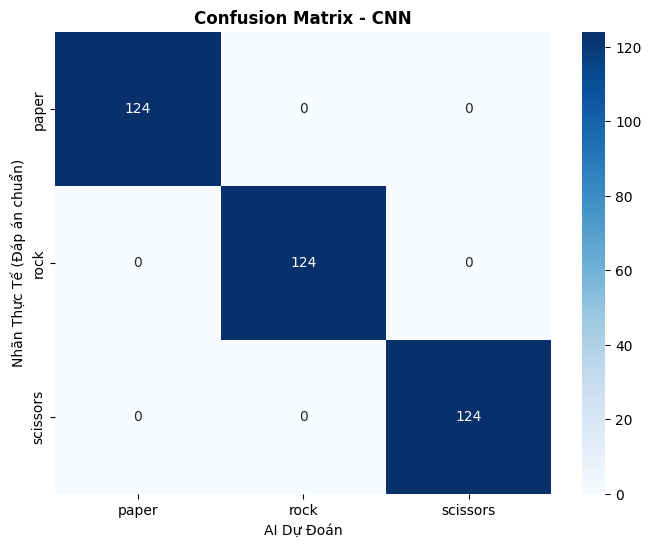


--- 3. BÁO CÁO CHI TIẾT ---
              precision    recall  f1-score   support

       paper       1.00      1.00      1.00       124
        rock       1.00      1.00      1.00       124
    scissors       1.00      1.00      1.00       124

    accuracy                           1.00       372
   macro avg       1.00      1.00      1.00       372
weighted avg       1.00      1.00      1.00       372



In [ ]:
# 1. IMPORT CÁC THƯ VIỆN CẦN THIẾT (Rất quan trọng)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

print("\n--- 1. KẾT QUẢ TỔNG QUAN ---")
# Đánh giá trên tập test
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Accuracy: {test_accuracy*100:.2f}%")

# 2. LƯU MÔ HÌNH (Đã sửa lại đường dẫn)
# Code này sẽ lưu file .keras ngay tại thư mục chứa file Jupyter Notebook của bạn
model_name = f'rps_cnn_v2_{test_accuracy*100:.0f}pct.keras' 
model.save(model_name)
print(f"\nĐã lưu mô hình thành công với tên: {model_name}")

print("\n--- 2. VẼ MA TRẬN NHẦM LẪN (CONFUSION MATRIX) ---")
# Lưu ý quan trọng: Tập test_generator của bạn BẮT BUỘC phải cài đặt shuffle=False
predictions = model.predict(test_generator)
y_pred = np.argmax(predictions, axis=1) # Chuyển xác suất thành nhãn AI đoán
y_true = test_generator.classes         # Nhãn đáp án thật

# Lấy tên các class (Paper, Rock, Scissors)
class_names = list(test_generator.class_indices.keys())

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - CNN', fontweight='bold')
plt.ylabel('Nhãn Thực Tế (Đáp án chuẩn)')
plt.xlabel('AI Dự Đoán')
plt.show()

print("\n--- 3. BÁO CÁO CHI TIẾT ---")
print(classification_report(y_true, y_pred, target_names=class_names))